## 1. Setup & Imports

In [1]:
!pip install scikit-learn pandas numpy matplotlib -q


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)

print("Libraries loaded successfully ")


Libraries loaded successfully ✅


2. Dataset Creation

In [4]:
GENRES = ["Action", "Comedy", "Drama", "Sci-Fi", "Romance",
          "Horror", "Thriller", "Animation", "Documentary", "Fantasy"]

MOVIE_TITLES = [
    "Edge of Tomorrow", "Silent Echoes", "The Last Horizon", "Midnight Comedy Hour",
    "Love in Autumn", "Shadows of the Mind", "Galaxy Runners", "Whispering Woods",
    "The Great Heist", "Laugh Track", "City of Dreams", "Beyond the Stars",
    "Dark Waters", "Sunset Boulevard Blues", "The Time Keeper", "Animated Adventures",
    "Real World Stories", "Enchanted Kingdom", "The Detective's Code", "Family Ties",
    "Cyber Rebellion", "Comedy Night Live", "Tears of Joy", "Haunted Manor",
    "Speed Chase", "Documentary: Ocean Life", "Fantasy Realm", "The Wedding Plan",
    "Zombie Outbreak", "Space Odyssey II", "Broken Hearts Club", "Mystery at Midnight",
    "The Comedy Trio", "War Stories", "Animated Kingdom", "Nature's Wonders",
    "The Last Stand", "Romantic Getaway", "Thriller Night", "Dragon's Legacy",
    "The Startup", "Comedy Central Movie", "Deep Sea Mystery", "Robot Uprising",
    "Summer Romance", "The Heist Crew", "Documentary: Space Race", "Fairy Tale Ending",
    "Undercover Agent", "Animated Heroes"
]

def make_movies(n=50):
    rows = []
    for i in range(n):
        primary = random.choice(GENRES)
        secondary_choices = [g for g in GENRES if g != primary]
        secondary = random.sample(secondary_choices, k=random.randint(1, 2))
        genres = [primary] + secondary
        desc = f"A {primary.lower()} story featuring elements of {' and '.join(secondary).lower()}."
        rows.append({
            "movie_id": i + 1,
            "title": MOVIE_TITLES[i % len(MOVIE_TITLES)] + (f" {i//len(MOVIE_TITLES)+1}" if i >= len(MOVIE_TITLES) else ""),
            "genres": "|".join(genres),
            "description": desc,
            "year": random.randint(2005, 2025)
        })
    return pd.DataFrame(rows)

movies = make_movies(50)

def make_users(n=25):
    rows = []
    for i in range(n):
        prefs = random.sample(GENRES, k=random.randint(2, 4))
        rows.append({
            "user_id": i + 1,
            "age": random.randint(18, 60),
            "preferred_genres": "|".join(prefs)
        })
    return pd.DataFrame(rows)

users = make_users(25)

def make_ratings(users_df, movies_df, density=0.35):
    rows = []
    for _, u in users_df.iterrows():
        prefs = set(u["preferred_genres"].split("|"))
        n_ratings = int(len(movies_df) * density)
        rated_movies = movies_df.sample(n=n_ratings, random_state=u["user_id"])
        for _, m in rated_movies.iterrows():
            movie_genres = set(m["genres"].split("|"))
            overlap = len(prefs & movie_genres)
            base = 2.5 + overlap * 1.0
            rating = np.clip(np.random.normal(base, 0.8), 1, 5)
            rows.append({
                "user_id": u["user_id"],
                "movie_id": m["movie_id"],
                "rating": round(rating * 2) / 2,  # nearest 0.5
                "timestamp": datetime.now() - timedelta(days=random.randint(0, 365))
            })
    return pd.DataFrame(rows)

ratings = make_ratings(users, movies)

print(f"Movies: {len(movies)} | Users: {len(users)} | Ratings: {len(ratings)}")
movies.head()


Movies: 50 | Users: 25 | Ratings: 425


,movie_id,title,genres,description,year
0,1,Edge of Tomorrow,Documentary|Comedy,A documentary story featuring elements of comedy.,2012
1,2,Silent Echoes,Thriller|Fantasy|Sci-Fi,A thriller story featuring elements of fantasy...,2020
2,3,The Last Horizon,Animation|Action|Comedy,A animation story featuring elements of action...,2014
3,4,Midnight Comedy Hour,Sci-Fi|Romance|Horror,A sci-fi story featuring elements of romance a...,2023
4,5,Love in Autumn,Horror|Fantasy|Thriller,A horror story featuring elements of fantasy a...,2018


In [ ]:
ratings.head()


3. User Profile Analysis

In [5]:
def build_user_profile(user_id):
    user_row = users[users.user_id == user_id].iloc[0]
    user_ratings = ratings[ratings.user_id == user_id].merge(movies, on="movie_id")

    if user_ratings.empty:
        return {
            "user_id": user_id,
            "stated_preferences": user_row["preferred_genres"].split("|"),
            "inferred_top_genres": [],
            "avg_rating_given": None,
            "num_ratings": 0
        }

    genre_scores = {}
    for _, row in user_ratings.iterrows():
        for g in row["genres"].split("|"):
            genre_scores.setdefault(g, []).append(row["rating"])

    genre_avg = {g: np.mean(v) for g, v in genre_scores.items()}
    top_genres = sorted(genre_avg, key=genre_avg.get, reverse=True)[:3]

    return {
        "user_id": user_id,
        "age": int(user_row["age"]),
        "stated_preferences": user_row["preferred_genres"].split("|"),
        "inferred_top_genres": top_genres,
        "avg_rating_given": round(user_ratings["rating"].mean(), 2),
        "num_ratings": len(user_ratings)
    }

profile = build_user_profile(1)
profile


{'user_id': 1,
 'age': 27,
 'stated_preferences': ['Animation', 'Documentary'],
 'inferred_top_genres': ['Documentary', 'Animation', 'Fantasy'],
 'avg_rating_given': np.float64(3.15),
 'num_ratings': 17}

4. Content-Based Filtering

In [6]:
movies["content"] = movies["genres"].str.replace("|", " ", regex=False) + " " + movies["description"]

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["content"])

content_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
content_sim_df = pd.DataFrame(content_sim, index=movies.movie_id, columns=movies.movie_id)

def content_based_recommend(user_id, n=5):
    user_ratings = ratings[ratings.user_id == user_id]
    liked = user_ratings[user_ratings.rating >= 4.0]["movie_id"].tolist()
    if not liked:
        liked = user_ratings.sort_values("rating", ascending=False)["movie_id"].head(3).tolist()
    if not liked:
        return movies.sample(n)[["movie_id", "title", "genres"]]

    scores = content_sim_df.loc[liked].mean(axis=0)
    already_seen = set(user_ratings.movie_id)
    scores = scores.drop(labels=[m for m in already_seen if m in scores.index], errors="ignore")

    top = scores.sort_values(ascending=False).head(n)
    return movies.set_index("movie_id").loc[top.index][["title", "genres"]].assign(score=top.values)

content_based_recommend(1, 5)


,title,genres,score
movie_id,,,
6,Shadows of the Mind,Documentary|Horror|Animation,0.514743
14,Sunset Boulevard Blues,Action|Documentary|Fantasy,0.473489
5,Love in Autumn,Horror|Fantasy|Thriller,0.418492
1,Edge of Tomorrow,Documentary|Comedy,0.410478
34,War Stories,Action|Documentary,0.399707


5. Similar Item Detection

In [7]:
def find_similar_movies(movie_id, n=5):
    if movie_id not in content_sim_df.index:
        raise ValueError("Unknown movie_id")
    scores = content_sim_df[movie_id].drop(index=movie_id)
    top = scores.sort_values(ascending=False).head(n)
    result = movies.set_index("movie_id").loc[top.index][["title", "genres"]].assign(similarity=top.values.round(3))
    return result

target_title = movies.iloc[0]["title"]
print(f"Because you watched: {target_title}")
find_similar_movies(movies.iloc[0]["movie_id"], 5)


Because you watched: Edge of Tomorrow


,title,genres,similarity
movie_id,,,
49,Undercover Agent,Comedy|Documentary,1.000
29,Zombie Outbreak,Romance|Documentary|Comedy,0.782
31,Broken Hearts Club,Comedy|Animation,0.550
16,Animated Adventures,Animation|Comedy,0.550
21,Cyber Rebellion,Fantasy|Comedy,0.540


6. Collaborative Filtering

In [8]:
user_item_matrix = ratings.pivot_table(index="user_id", columns="movie_id", values="rating").fillna(0)

n_components = min(10, min(user_item_matrix.shape) - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_matrix = svd.fit_transform(user_item_matrix)
reconstructed = np.dot(latent_matrix, svd.components_)

predicted_ratings = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

def collaborative_recommend(user_id, n=5):
    already_seen = set(ratings[ratings.user_id == user_id]["movie_id"])
    preds = predicted_ratings.loc[user_id].drop(labels=[m for m in already_seen if m in predicted_ratings.columns])
    top = preds.sort_values(ascending=False).head(n)
    return movies.set_index("movie_id").loc[top.index][["title", "genres"]].assign(predicted_rating=top.values.round(2))

collaborative_recommend(1, 5)


,title,genres,predicted_rating
movie_id,,,
6,Shadows of the Mind,Documentary|Horror|Animation,1.49
12,Beyond the Stars,Documentary|Romance,1.31
17,Real World Stories,Animation|Action,1.30
35,Animated Kingdom,Animation|Drama|Thriller,1.02
24,Haunted Manor,Thriller|Documentary|Romance,0.94


7. Hybrid Recommendation Model

In [9]:
def _normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

def hybrid_recommend(user_id, n=5, content_weight=0.5, collab_weight=0.5):
    already_seen = set(ratings[ratings.user_id == user_id]["movie_id"])
    candidates = [m for m in movies.movie_id if m not in already_seen]

    # content-based score: avg similarity to user's liked movies
    liked = ratings[(ratings.user_id == user_id) & (ratings.rating >= 4.0)]["movie_id"].tolist()
    if not liked:
        liked = ratings[ratings.user_id == user_id].sort_values("rating", ascending=False)["movie_id"].head(3).tolist()
    if liked:
        content_scores = content_sim_df.loc[liked, candidates].mean(axis=0)
    else:
        content_scores = pd.Series(0, index=candidates)

    # collaborative score
    collab_scores = predicted_ratings.loc[user_id, candidates]

    combined = pd.DataFrame({
        "content": _normalize(content_scores),
        "collab": _normalize(collab_scores)
    })
    combined["hybrid_score"] = content_weight * combined["content"] + collab_weight * combined["collab"]

    top = combined.sort_values("hybrid_score", ascending=False).head(n)
    return movies.set_index("movie_id").loc[top.index][["title", "genres"]].assign(
        hybrid_score=top["hybrid_score"].values.round(3))

hybrid_recommend(1, 5)


,title,genres,hybrid_score
movie_id,,,
6,Shadows of the Mind,Documentary|Horror|Animation,1.000
12,Beyond the Stars,Documentary|Romance,0.772
24,Haunted Manor,Thriller|Documentary|Romance,0.771
1,Edge of Tomorrow,Documentary|Comedy,0.746
17,Real World Stories,Animation|Action,0.719


8. Personalized Suggestions

In [10]:
def personalized_suggestions(user_id, n=5):
    profile = build_user_profile(user_id)
    preferred = set(profile["stated_preferences"])

    base = hybrid_recommend(user_id, n=n * 3)  # over-fetch, then re-rank
    def genre_boost(genres_str):
        movie_genres = set(genres_str.split("|"))
        return len(movie_genres & preferred) * 0.05

    base = base.copy()
    base["final_score"] = base["hybrid_score"] + base["genres"].apply(genre_boost)
    base = base.sort_values("final_score", ascending=False).head(n)

    print(f"👤 User {user_id} | Age {profile.get('age', '-')}")
    print(f"   Stated preferences: {', '.join(profile['stated_preferences'])}")
    print(f"   Inferred top genres (from behavior): {', '.join(profile['inferred_top_genres']) or 'N/A'}")
    print(f"   Avg rating given: {profile['avg_rating_given']} across {profile['num_ratings']} ratings\n")
    return base[["title", "genres", "final_score"]]

personalized_suggestions(1, 5)


👤 User 1 | Age 27
   Stated preferences: Animation, Documentary
   Inferred top genres (from behavior): Documentary, Animation, Fantasy
   Avg rating given: 3.15 across 17 ratings



,title,genres,final_score
movie_id,,,
6,Shadows of the Mind,Documentary|Horror|Animation,1.100
12,Beyond the Stars,Documentary|Romance,0.822
24,Haunted Manor,Thriller|Documentary|Romance,0.821
1,Edge of Tomorrow,Documentary|Comedy,0.796
17,Real World Stories,Animation|Action,0.769


9. Recommendation History

In [11]:
recommendation_history = []

def log_recommendations(user_id, recs_df, strategy):
    timestamp = datetime.now()
    for movie_id, row in recs_df.iterrows():
        recommendation_history.append({
            "user_id": user_id,
            "movie_id": movie_id,
            "title": row["title"],
            "strategy": strategy,
            "score": row.get("final_score", row.get("hybrid_score", row.get("score", None))),
            "timestamp": timestamp
        })

def get_recommendation_history(user_id=None):
    df = pd.DataFrame(recommendation_history)
    if df.empty:
        return df
    if user_id is not None:
        df = df[df.user_id == user_id]
    return df.sort_values("timestamp", ascending=False)

# Generate & log a few rounds of recommendations
for uid in [1, 2, 3]:
    recs = personalized_suggestions(uid, 5)
    log_recommendations(uid, recs, strategy="hybrid")
    print("-" * 60)

get_recommendation_history(user_id=1)


👤 User 1 | Age 27
   Stated preferences: Animation, Documentary
   Inferred top genres (from behavior): Documentary, Animation, Fantasy
   Avg rating given: 3.15 across 17 ratings

------------------------------------------------------------
👤 User 2 | Age 22
   Stated preferences: Sci-Fi, Documentary, Drama
   Inferred top genres (from behavior): Sci-Fi, Fantasy, Drama
   Avg rating given: 3.03 across 17 ratings

------------------------------------------------------------
👤 User 3 | Age 18
   Stated preferences: Thriller, Horror, Romance
   Inferred top genres (from behavior): Thriller, Horror, Animation
   Avg rating given: 3.21 across 17 ratings

------------------------------------------------------------


,user_id,movie_id,title,strategy,score,timestamp
0,1,6,Shadows of the Mind,hybrid,1.100,2026-08-12 14:10:49.277768
1,1,12,Beyond the Stars,hybrid,0.822,2026-08-12 14:10:49.277768
2,1,24,Haunted Manor,hybrid,0.821,2026-08-12 14:10:49.277768
3,1,1,Edge of Tomorrow,hybrid,0.796,2026-08-12 14:10:49.277768
4,1,17,Real World Stories,hybrid,0.769,2026-08-12 14:10:49.277768


## 10. Evaluation & Visualization

In [12]:
# Simple offline evaluation: RMSE of the collaborative-filtering reconstruction
# against the ratings actually observed (sanity check on the SVD model).
mask = user_item_matrix.values > 0
actual = user_item_matrix.values[mask]
predicted = reconstructed[mask]
rmse = np.sqrt(np.mean((actual - predicted) ** 2))
print(f"Collaborative filtering RMSE on observed ratings: {rmse:.3f}")


Collaborative filtering RMSE on observed ratings: 1.096


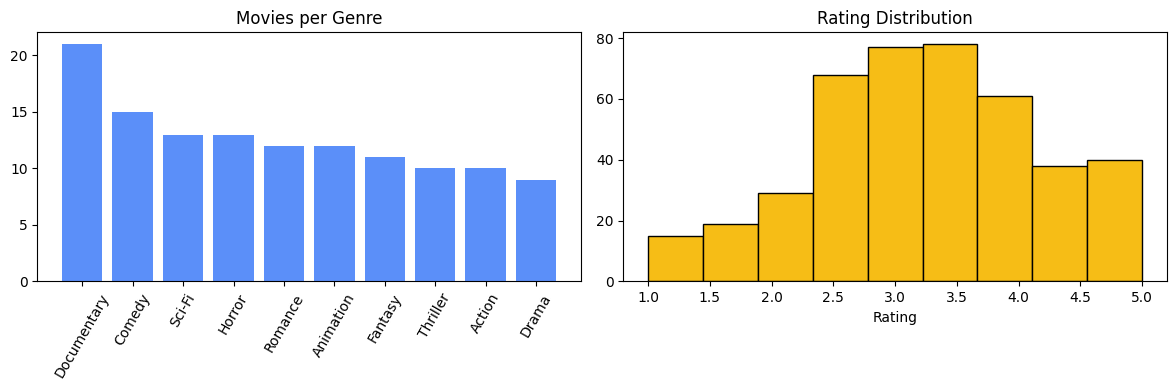

In [13]:
# Visualize genre distribution across the catalog and rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

genre_counts = movies["genres"].str.split("|").explode().value_counts()
axes[0].bar(genre_counts.index, genre_counts.values, color="#5B8FF9")
axes[0].set_title("Movies per Genre")
axes[0].tick_params(axis="x", rotation=60)

axes[1].hist(ratings["rating"], bins=9, color="#F6BD16", edgecolor="black")
axes[1].set_title("Rating Distribution")
axes[1].set_xlabel("Rating")

plt.tight_layout()
plt.show()


11. Try It Yourself

In [14]:
demo_user = 7
_ = personalized_suggestions(demo_user, 5)


👤 User 7 | Age 38
   Stated preferences: Thriller, Sci-Fi, Fantasy, Action
   Inferred top genres (from behavior): Documentary, Action, Sci-Fi
   Avg rating given: 3.29 across 17 ratings



## 12. Using Real Data (Optional Upgrade)

To swap in the real **MovieLens** dataset instead of the synthetic one:

```python
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip -q
!unzip -q ml-latest-small.zip
movies = pd.read_csv('ml-latest-small/movies.csv')
movies = movies.rename(columns={'movieId': 'movie_id'})
ratings = pd.read_csv('ml-latest-small/ratings.csv')
ratings = ratings.rename(columns={'userId': 'user_id', 'movieId': 'movie_id'})
```

Then re-run the notebook from **Section 3 onward** (skip the synthetic data
cells) — all the recommendation functions work unchanged since they only
depend on the `movies`/`ratings` column names.

### Project Summary
| Feature | Technique Used |
|---|---|
| User Profile Analysis | Aggregated rating behavior + stated preferences |
| Content-Based Filtering | TF-IDF + Cosine Similarity |
| Similar Item Detection | Cosine similarity matrix lookup |
| Collaborative Filtering | Matrix factorization (Truncated SVD) |
| Hybrid Recommendation Model | Weighted, normalized blend of both scores |
| Personalized Suggestions | Hybrid scores + genre-preference re-ranking |
| Recommendation History | In-memory log (timestamp, strategy, score) |
